In [42]:
import os
from zipfile import ZipFile
from pathlib import Path
import requests

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

%matplotlib inline
from matplotlib import pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 9)
plt.rcParams["font.family"] = "DejaVu Sans"

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

In [43]:
def load_har_dataset(url, extract_path: Path, filename: str, overwrite=False):
    extract_path.mkdir(parents=True, exist_ok=True)
    filepath = extract_path / filename

    if filepath.exists() and not overwrite:
        print("Using the existing dataset archive.")
    else:
        print("Downloading the dataset from: ", url)
        response = requests.get(url)
        response.raise_for_status()

        with open(filepath, 'wb') as f:
            f.write(response.content)

    with ZipFile(filepath, 'r') as zipObj:
        zipObj.extractall(extract_path)

In [44]:
FILE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
FILE_NAME = "UCI HAR Dataset.zip"
DATA_PATH = Path("data/large_files")

load_har_dataset(url=FILE_URL, extract_path=DATA_PATH, filename=FILE_NAME)

PATH_TO_SAMSUNG_DATA = DATA_PATH / Path(FILE_NAME).stem

Using the existing dataset archive.


In [45]:
X_train = np.loadtxt(PATH_TO_SAMSUNG_DATA / "train" / "X_train.txt")
y_train = np.loadtxt(PATH_TO_SAMSUNG_DATA / "train" / "y_train.txt").astype(int)

X_test = np.loadtxt(PATH_TO_SAMSUNG_DATA / "test" / "X_test.txt")
y_test = np.loadtxt(PATH_TO_SAMSUNG_DATA / "test" / "y_test.txt").astype(int)

In [46]:
# Checking dimensions
assert X_train.shape == (7352, 561) and y_train.shape == (7352,)
assert X_test.shape == (2947, 561) and y_test.shape == (2947,)

In [47]:
# merge train and test samples
# Your code here
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])

In [48]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

In [49]:
n_classes = np.unique(y).size
n_classes

6

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [51]:
# reduce the dimension of the dataset, leveaning explanatuin of 90% of variance
pca = PCA(n_components=0.9, random_state=RANDOM_STATE).fit(X_scaled)
X_pca = pca.transform(X_scaled)

---

#### Question 1:
What is the minimum number of principal components required to cover the 90% of the variance of the original (scaled) data?

**65**

In [52]:
X_pca.shape

(10299, 65)

#### Question 2:
What percentage of the variance is covered by the first principal component? Round to the nearest percent.

In [53]:
pca.explained_variance_ratio_[0]

np.float64(0.5073822103501334)

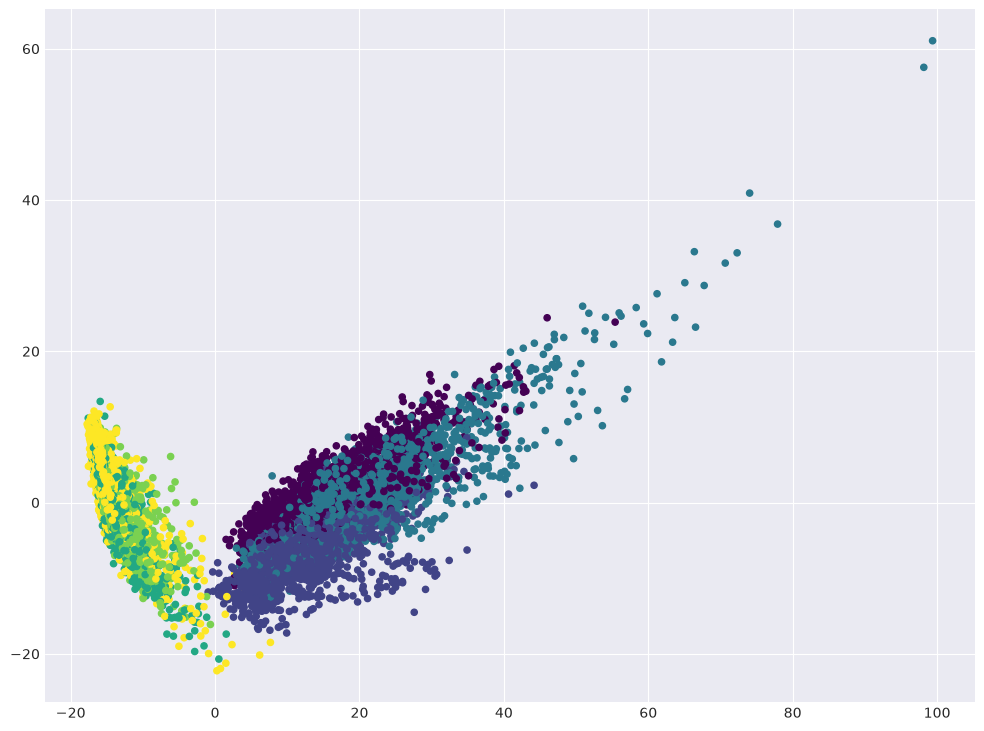

In [54]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap="viridis")

#### Question 3:
If everything worked out correctly, you will see a number of clusters, almost perfectly separated from each other. What types of activity are included in these clusters?

In [55]:
kmeans = KMeans(n_clusters=n_classes, random_state=RANDOM_STATE, n_init=100)
kmeans.fit(X_pca)
cluster_labels = kmeans.labels_

cluster_labels

array([0, 0, 0, ..., 1, 1, 1], shape=(10299,), dtype=int32)

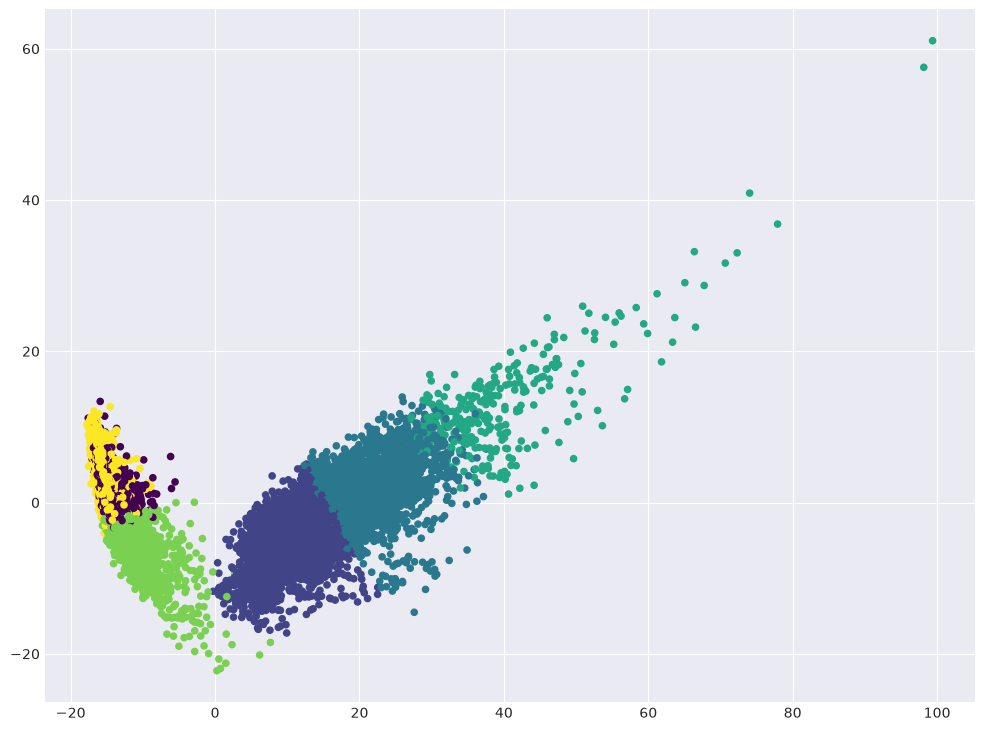

In [56]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, s=20, cmap="viridis")

In [57]:
tab = pd.crosstab(y, cluster_labels, margins=True)
tab.index = [
    "walking",
    "going up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "laying",
    "all",
]
tab.columns = ["cluster" + str(i + 1) for i in range(6)] + ["all"]
tab

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,all
walking,0,903,741,78,0,0,1722
going up the stairs,0,1241,296,5,2,0,1544
going down the stairs,0,320,890,196,0,0,1406
sitting,1235,1,0,0,450,91,1777
standing,1344,0,0,0,562,0,1906
laying,52,5,0,0,329,1558,1944
all,2631,2470,1927,279,1343,1649,10299


We see that for each class (i.e., each activity) there are several clusters. Let’s look at the maximum percentage of objects in a class that are assigned to a single cluster. This will be a simple metric that characterizes how easily the class is separated from others when clustering.

Example: if for class “walking downstairs” (with 1406 instances belonging to it), the distribution of clusters is:

- cluster 1 - 900
- cluster 3 - 500
- cluster 6 - 6,

then such a share will be 900/1406 $\approx$ 0.64.



#### Question 4:
Which activity is separated from the rest better than others based on the simple metric described above?

In [58]:
tab.shape

(7, 7)

In [59]:
pd.Series(tab.iloc[:-1, :-1].max(axis=1).values / tab.iloc[:-1, -1].values, index=tab.index[:-1])

walking                  0.524390
going up the stairs      0.803756
going down the stairs    0.633001
sitting                  0.694992
standing                 0.705142
laying                   0.801440
dtype: float64

In [60]:
from tqdm.auto import tqdm
inertia = []
for k in tqdm(range(1, n_classes + 1)):
    kmeans = KMeans(n_clusters=k, n_init=100, random_state=RANDOM_STATE).fit(X_pca)
    inertia.append(np.sqrt(kmeans.inertia_))

  0%|          | 0/6 [00:00<?, ?it/s]

$$\text{inertia} = \sum_{i=1}^{n} \left| x_i - \mu_{c_i} \right|^2$$

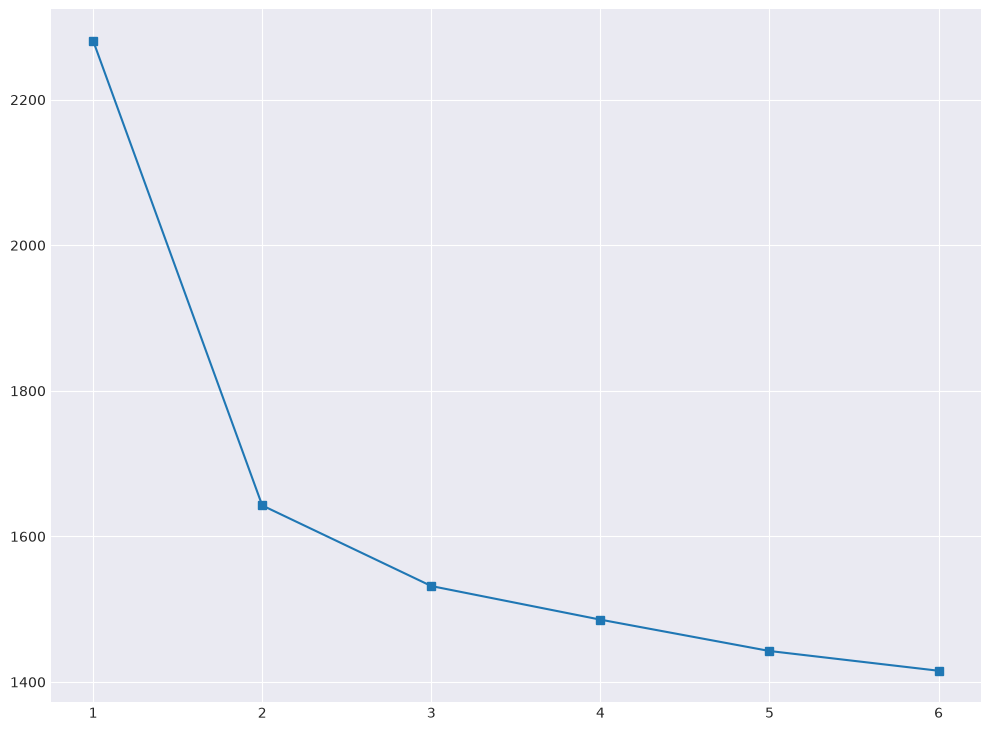

In [61]:
plt.plot(range(1,7), inertia, marker='s')

$$D(k) = \frac{\text{inertia}[i] - \text{inertia}[i+1]}{\text{inertia}[i-1] - \text{inertia}[i]}$$
$$D(k) = \frac{I(k) - I(k+1)}{I(k-1) - I(k)}$$

In [62]:
d = {}
for k in range(2, 6):
    i = k - 1
    d[k] = (inertia[i] - inertia[i + 1]) / (inertia[i - 1] - inertia[i])
    
d

{2: np.float64(0.1734475356009408),
 3: np.float64(0.4168855575586398),
 4: np.float64(0.9332198909748944),
 5: np.float64(0.6297014287707643)}

#### Question 5:
How many clusters can we choose according to the elbow method?

In [63]:
ag = AgglomerativeClustering(n_clusters=n_classes, linkage="ward").fit(X_pca)

In [64]:
print("KMeans: ARI =", metrics.adjusted_rand_score(y, cluster_labels))
print("Agglomerative CLustering: ARI =", metrics.adjusted_rand_score(y, ag.labels_))

KMeans: ARI = 0.4198070012602345
Agglomerative CLustering: ARI = 0.49362763373004886


#### Question 6:
Select all the correct statements.

**Answer options:**

- According to ARI, KMeans handled clustering worse than Agglomerative Clustering [+]
- For ARI, it does not matter which tags are assigned to the cluster, only the partitioning of instances into clusters matters [+]
- In case of random partitioning into clusters, ARI will be close to zero [+]

Comment:
1. Yes, the higher ARI, the better
2. Yes, if you renumber clusters differently, ARI will not change
3. True



In [65]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {"C": [0.001, 0.01, 0.1, 1, 10]}

In [68]:
best_svc = GridSearchCV(svc, svc_params, n_jobs=4, cv=3, verbose=1)
best_svc.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/Users/samuelbagin/Desktop/code/ml-course/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/samuelbagin/Desktop/code/ml-course/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/samuelbagin/Desktop/code/ml-course/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a 

In [69]:
best_svc.best_params_, best_svc.best_score_

({'C': 0.1}, np.float64(0.9379785010699506))

#### Question 7
Which value of the hyperparameter C was chosen the best on the basis of cross-validation?
**0.1**

In [70]:
y_predicted = best_svc.predict(X_test_scaled)

In [73]:
tab = pd.crosstab(y_test, y_predicted, margins=True)
tab.index = [
    "walking",
    "climbing up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "laying",
    "all",
]
tab.columns = [
    "walking",
    "climbing up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "laying",
    "all",
]

# 6x6 core of real counts (drop the 'all' margins)
core = tab.iloc[:-1, :-1]
diag = np.diag(core)                 # true positives per class

# recall = TP / row total (per TRUE class)  -> add as a COLUMN
tab["recall"] = (diag / core.sum(axis=1)).round(3)

# precision = TP / column total (per PREDICTED class) -> add as a ROW
tab.loc["precision"] = (diag / core.sum(axis=0)).round(3)

tab

# rows - test
# columns - predicted

,walking,climbing up the stairs,going down the stairs,sitting,standing,laying,all,recall
walking,494.000,2.000,0.0,0.000,0.000,0.0,496.0,0.996
climbing up the stairs,12.000,459.000,0.0,0.000,0.000,0.0,471.0,0.975
going down the stairs,2.000,4.000,413.0,1.000,0.000,0.0,420.0,0.983
sitting,0.000,4.000,0.0,426.000,61.000,0.0,491.0,0.868
standing,0.000,0.000,0.0,15.000,517.000,0.0,532.0,0.972
laying,0.000,0.000,0.0,0.000,11.000,526.0,537.0,0.980
all,508.000,469.000,413.0,442.000,589.000,526.0,2947.0,NaN
precision,0.972,0.979,1.0,0.964,0.878,1.0,NaN,NaN


axis` names the axis that disappears, not the one you keep. ‎`sum(axis=0)` removes the rows → leaves column totals. ‎`sum(axis=1)` removes the columns → leaves row totals

The ‎`axis=` argument tells pandas/NumPy which direction to move when it collapses or applies an operation across a 2D table

In [ ]:
diag

array([494, 459, 413, 426, 517, 526])

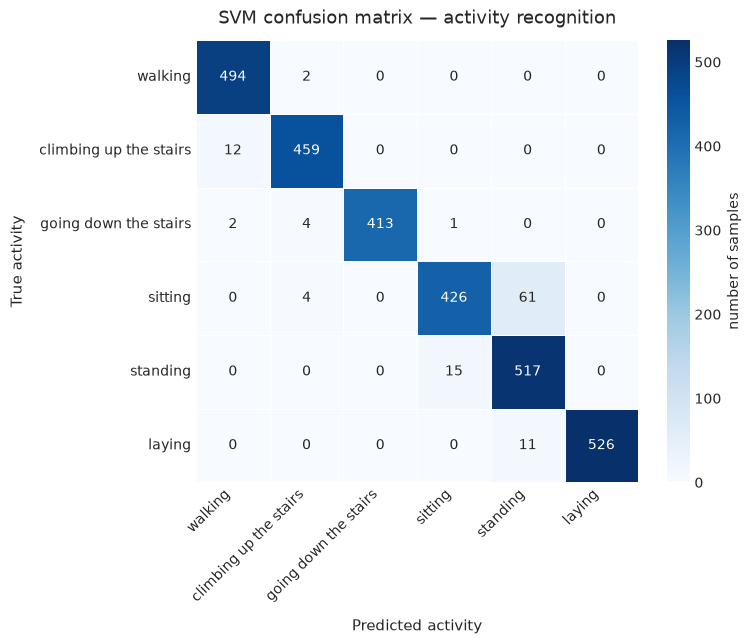

In [72]:
from sklearn.metrics import confusion_matrix

labels = [
    "walking",
    "climbing up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "laying",
]

# Build the raw confusion matrix (rows = true, cols = predicted), no margins
cm = confusion_matrix(y_test, y_predicted)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    cm_df,
    annot=True,          # write the counts in each cell
    fmt="d",             # integer formatting
    cmap="Blues",        # light = few, dark = many
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "number of samples"},
    square=True,
    ax=ax,
)

ax.set_xlabel("Predicted activity", fontsize=11, labelpad=10)
ax.set_ylabel("True activity", fontsize=11, labelpad=10)
ax.set_title("SVM confusion matrix — activity recognition", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### Question 8:
Which activity type is worst detected by SVM in terms of precision? Recall?

Answer options:
- precision – going up the stairs, recall – laying
- precision – laying, recall – sitting
- precision – walking, recall – walking
- **precision – standing, recall – sitting [+]**

#### Question 9:
What is the difference between the best quality (accuracy) for cross-validation in the case of all 561 initial characteristics and in the second case, when the principal component method was applied? Round to the nearest percent.

In [76]:
# Your code here
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [77]:
svc = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)
svc_params = {"C": [0.001, 0.01, 0.1, 1, 10]}

In [78]:
%%time
best_svc_pca = GridSearchCV(svc, svc_params, n_jobs=4, cv=3, verbose=1)
best_svc_pca.fit(X_train_pca, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
CPU times: user 178 ms, sys: 48 ms, total: 226 ms
Wall time: 3.26 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(max...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy usin

In [79]:
best_svc_pca.best_params_, best_svc_pca.best_score_

({'C': 0.1}, np.float64(0.8983982658750974))

In [80]:
round(100 * (best_svc_pca.best_score_ - best_svc.best_score_))

-4

#### Question 10:
Select all the correct statements:

Answer options:
- Principal component analysis in this case allowed us to reduce the model training time, while the quality (mean cross-validation accuracy) suffered greatly, by more than 10%
- PCA can be used to visualize data, but there are better methods for this task, for example, tSNE. However, PCA has lower computational complexity [+]
- PCA builds linear combinations of initial features, and in some applications they might be poorly interpreted by humans [+]

Comment:
1. The first statement is true, principal component analysis in this case allowed us to significantly reduce the training time of the model, but the quality suffered not so much – by only 4%
2. For multidimensional data visualization it is better to use manifold learning methods, in particular, tSNE. At the same time, metrics assessing the quality of visualization have not really been invented yet, but tSNE is widely used precisely because in some cases it builds “good” pictures showing the data structure, as in the case of MNIST
3. Linear combinations of features, that PCA builds, are often poorly interpreted by humans, for example, 0.574 * salary + 0.234 * num_children

## Notes
### 1. Scaling (`StandardScaler`) ￼
`StandardScaler` transforms each feature to have mean 0 and standard deviation 1. Two reasons it comes first:
- PCA demands it. PCA finds the directions of maximum variance. If features are on different scales (say one ranges 0–1000 and another 0–1), the big-scale feature dominates the variance purely because of its units, and PCA would pick it as the top component regardless of whether it’s actually informative. Standardizing puts every feature on equal footing so PCA measures real structure, not unit artifacts.
- SVMs need it too. LinearSVC minimizes a distance/margin-based objective, which is also sensitive to feature scale. Unscaled features distort the margin and slow convergence.

### 2. PCA (`n_components=0.9`) ￼
After scaling, PCA compresses the 561 original features down to the smallest set of principal components that still retains 90% of the variance (that’s what ‎`n_components=0.9` means — a variance target, not a fixed count). Why do this before the classifier:
- Dimensionality reduction. 561 features is a lot; many are correlated (this is sensor data — accelerometer/gyroscope readings overlap heavily). PCA collapses that redundancy into far fewer uncorrelated components.
- Speed. Fewer features means the ‎`GridSearchCV` over 5 values of ‎`C` with 3-fold CV trains much faster. That’s the whole point of the comparison on this page — Question 9 asks how much accuracy you give up by using PCA-compressed features instead of all 561.
- Noise reduction / less overfitting. Dropping the low-variance directions often removes noise.

### 3. LinearSVC + GridSearchCV ￼
`LinearSVC` is a linear support vector classifier — a strong, fast baseline for high-dimensional data like this. `GridSearchCV` with `svc_params = {"C": [...]}` tunes the regularization strength `C` (low C = more regularization/simpler boundary, high C = fits training data harder) using 3-fold cross-validation, and `n_jobs=4` parallelizes it. The `max_iter=5000` just gives the solver enough iterations to converge.